In [1]:
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.clustering import KMeans
import matplotlib.pyplot as plt
import pandas as pd
from pyspark.sql import functions as F

# Khởi tạo Spark Session có hỗ trợ Hive và Delta
spark = SparkSession.builder \
    .appName("KMeans_Research_Tuning") \
    .config("spark.sql.catalogImplementation", "hive") \
    .config("hive.metastore.uris", "thrift://hive-metastore:9083") \
    .enableHiveSupport() \
    .getOrCreate()

spark.sql("SHOW TABLES FROM gold_db").show()

+---------+-----------------+-----------+
|namespace|        tableName|isTemporary|
+---------+-----------------+-----------+
|  gold_db|     dim_products|      false|
|  gold_db|      fact_events|      false|
|  gold_db|user_interactions|      false|
|  gold_db|  behavior_funnel|      false|
|  gold_db|     top_trending|      false|
|  gold_db|         user_rfm|      false|
+---------+-----------------+-----------+



In [2]:
# Đọc dữ liệu từ bảng Gold
rfm_df = spark.table("gold_db.user_rfm")

# Vecto hóa: Gom 3 cột R, F, M thành 1 cột 'features'
assembler = VectorAssembler(
    inputCols=["recency", "frequency", "monetary"], 
    outputCol="features"
)
feature_df = assembler.transform(rfm_df)

# Standardization: Chuẩn hóa dữ liệu về cùng thang đo (Z-score) 
scaler = StandardScaler(
    inputCol="features", 
    outputCol="scaledFeatures", 
    withStd=True, 
    withMean=True
)
scaler_model = scaler.fit(feature_df)
final_data = scaler_model.transform(feature_df)

final_data.select("user_id", "scaledFeatures").show(5, truncate=False)

+-------------------+-------------------------------------------------------------+
|user_id            |scaledFeatures                                               |
+-------------------+-------------------------------------------------------------+
|1515915625540633297|[0.5187739917942105,-0.1644036623642297,-0.11324989735057596]|
|1515915625540738672|[0.5187739917942105,-0.1644036623642297,-0.11324989735057596]|
|1515915625540786287|[0.5187739917942105,-0.1644036623642297,-0.11324989735057596]|
|1515915625540837670|[0.5187739917942105,-0.1644036623642297,-0.11324989735057596]|
|1515915625540861078|[0.5187739917942105,5.214822710880335,2.22164594836696]      |
+-------------------+-------------------------------------------------------------+
only showing top 5 rows



Hoàn thành K=2 | WSSSE=906307.69
Hoàn thành K=3 | WSSSE=544439.66
Hoàn thành K=4 | WSSSE=397503.84
Hoàn thành K=5 | WSSSE=329120.83
Hoàn thành K=6 | WSSSE=545577.16
Hoàn thành K=7 | WSSSE=239213.78
Hoàn thành K=8 | WSSSE=214823.27
Hoàn thành K=9 | WSSSE=186145.62
Hoàn thành K=10 | WSSSE=160713.42


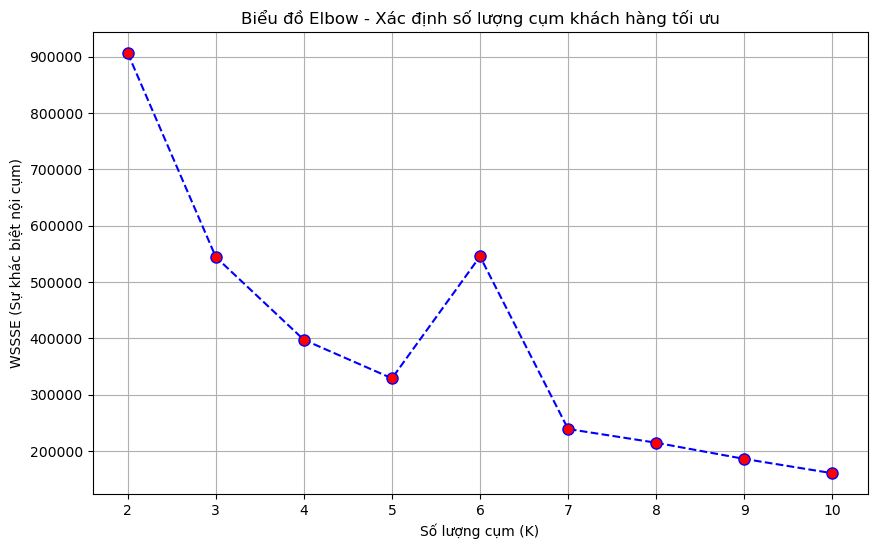

In [4]:
# thưc hiện phương pháp elbow để tìm K tối ưu 
cost = []

for k in range(2, 11):
    kmeans = KMeans(featuresCol="scaledFeatures", k=k, seed=42)
    model = kmeans.fit(final_data)
    
    # trainingCost là tổng bình phương khoảng cách, WSSSE là sai số nội cụm
    wssse = model.summary.trainingCost
    
    cost.append(wssse)
    print(f"Hoàn thành K={k} | WSSSE={wssse:.2f}")

# Vẽ biểu đồ Elbow 
plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), cost, color='blue', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=8)
plt.title('Biểu đồ Elbow - Xác định số lượng cụm khách hàng tối ưu')
plt.xlabel('Số lượng cụm (K)')
plt.ylabel('WSSSE (Sự khác biệt nội cụm)')
plt.grid(True)
plt.show()

In [5]:
# CHỌN K TỐI ƯU (Thay số 4 bằng số m thấy trên biểu đồ)
best_k = 4 

kmeans_final = KMeans(featuresCol="scaledFeatures", k=best_k, seed=42)
model_final = kmeans_final.fit(final_data)

# Dự đoán cụm cho từng khách hàng
predictions = model_final.transform(final_data)

# Thống kê đặc điểm các cụm
print(f"--- ĐẶC ĐIỂM {best_k} CỤM KHÁCH HÀNG ---")
cluster_stats = predictions.groupBy("prediction").agg(
    F.count("user_id").alias("User_Count"),
    F.round(F.avg("recency"), 2).alias("Avg_Recency"),
    F.round(F.avg("frequency"), 2).alias("Avg_Freq"),
    F.round(F.avg("monetary"), 2).alias("Avg_Spend")
).orderBy("Avg_Spend", ascending=False)

cluster_stats.show()

--- ĐẶC ĐIỂM 4 CỤM KHÁCH HÀNG ---
+----------+----------+-----------+--------+---------+
|prediction|User_Count|Avg_Recency|Avg_Freq|Avg_Spend|
+----------+----------+-----------+--------+---------+
|         1|       735|      52.14|    6.65|   1810.8|
|         2|     10434|      65.24|    2.14|   310.76|
|         3|    206445|     116.93|    0.03|     1.42|
|         0|    189669|      37.47|    0.02|     1.37|
+----------+----------+-----------+--------+---------+



In [7]:

from pyspark.sql import functions as F

# Ánh xạ ID cụm sang Tên nhóm khách hàng 
final_clusters = predictions.withColumn("segment_name", 
    F.when(F.col("prediction") == 1, "Champions")
     .when(F.col("prediction") == 2, "Loyal")
     .when(F.col("prediction") == 0, "Recent Browsers") 
     .otherwise("At Risk")
).select(
    F.col("user_id"), 
    F.col("prediction").alias("cluster_id"), 
    F.col("segment_name")
)

# Ghi vào tầng Gold (Delta Table) 
final_clusters.write.format("delta").mode("overwrite") \
    .option("overwriteSchema", "true") \
    .option("path", "s3a://gold/user_clusters") \
    .saveAsTable("gold_db.user_clusters")

print("--- Đã lưu nhãn phân cụm khách hàng thành công vào gold_db.user_clusters! ---")

# Xem thử kết quả cuối cùng
spark.table("gold_db.user_clusters").show(10)

--- Đã lưu nhãn phân cụm khách hàng thành công vào gold_db.user_clusters! ---
+-------------------+----------+------------+
|            user_id|cluster_id|segment_name|
+-------------------+----------+------------+
|1515915625540633297|         3|     At Risk|
|1515915625540738672|         3|     At Risk|
|1515915625540786287|         3|     At Risk|
|1515915625540837670|         3|     At Risk|
|1515915625540861078|         2|       Loyal|
|1515915625540914755|         3|     At Risk|
|1515915625540692664|         3|     At Risk|
|1515915625537602934|         3|     At Risk|
|1515915625539232620|         3|     At Risk|
|1515915625538905572|         3|     At Risk|
+-------------------+----------+------------+
only showing top 10 rows

